# 深度卷積神經網路（AlexNet）
:label:`sec_alexnet`

在LeNet提出後，卷積神經網路在電腦視覺和機器學習領域中很有名氣。但卷積神經網路並沒有主導這些領域。這是因為雖然LeNet在小數據集上取得了很好的效果，但是在更大、更真實的數據集上訓練卷積神經網路的性能和可行性還有待研究。事實上，在上世紀90年代初到2012年之間的大部分時間裡，神經網路往往被其他機器學習方法超越，如支援向量機（support vector machines）。

在計算機視覺中，直接將神經網路與其他機器學習方法進行比較也許不公平。這是因為，卷積神經網路的輸入是由原始像素值或是經過簡單預處理（例如居中、縮放）的像素值組成的。但在使用傳統機器學習方法時，從業者永遠不會將原始像素作為輸入。在傳統機器學習方法中，計算機視覺流水線是由經過人的手工精心設計的特徵流水線組成的。對於這些傳統方法，大部分的進展都來自於對特徵有了更聰明的想法，並且學習到的算法往往歸於事後的解釋。

雖然上世紀90年代就有了一些神經網路加速卡，但僅靠它們還不足以開發出有大量參數的深層多通道多層卷積神經網路。此外，當時的數據集仍然相對較小。除了這些障礙，訓練神經網路的一些關鍵技巧仍然缺失，包括啟發式參數初始化、隨機梯度下降的變體、非擠壓激活函數和有效的正則化技術。

因此，與訓練*端到端*（從像素到分類結果）系統不同，經典機器學習的流水線看起來更像下面這樣：

1. 獲取一個有趣的數據集。在早期，收集這些數據集需要昂貴的傳感器（當時最先進的圖像也就100萬像素）。
2. 根據光學、幾何學、其他知識以及偶然的發現，手工對特徵數據集進行預處理。
3. 通過標準的特徵提取算法，如SIFT（尺度不變特徵變換） :cite:`Lowe.2004`和SURF（加速魯棒特徵） :cite:`Bay.Tuytelaars.Van-Gool.2006`或其他手動調整的流水線來輸入數據。
4. 將提取的特徵送入最喜歡的分類器中（例如線性模型或其它核方法），以訓練分類器。

當人們和機器學習研究人員交談時，會發現機器學習研究人員相信機器學習既重要又美麗：優雅的理論去證明各種模型的性質。機器學習是一個正在蓬勃發展、嚴謹且非常有用的領域。然而，當人們和計算機視覺研究人員交談，會聽到一個完全不同的故事。計算機視覺研究人員會告訴一個詭異的事實————推動領域進步的是數據特徵，而不是學習算法。計算機視覺研究人員相信，從對最終模型精度的影響來說，更大或更乾淨的數據集、或是稍微改進的特徵提取，比任何學習算法帶來的進步要大得多。

## 學習表徵

另一種預測這個領域發展的方法————觀察圖像特徵的提取方法。在2012年前，圖像特徵都是機械地計算出來的。事實上，設計一套新的特徵函數、改進結果，並撰寫論文是盛極一時的潮流。SIFT :cite:`Lowe.2004`、SURF :cite:`Bay.Tuytelaars.Van-Gool.2006`、HOG（定向梯度直方圖） :cite:`Dalal.Triggs.2005`、[bags of visual words](https://en.wikipedia.org/wiki/Bag-of-words_model_in_computer_vision)和類似的特徵提取方法佔據了主導地位。

另一組研究人員，包括Yann LeCun、Geoff Hinton、Yoshua Bengio、Andrew Ng、Shun ichi Amari和Juergen Schmidhuber，想法則與眾不同：他們認為特徵本身應該被學習。此外，他們還認為，在合理地複雜性前提下，特徵應該由多個共同學習的神經網路層組成，每個層都有可學習的參數。在機器視覺中，最底層可能檢測邊緣、顏色和紋理。事實上，Alex Krizhevsky、Ilya Sutskever和Geoff Hinton提出了一種新的卷積神經網路變體*AlexNet*。在2012年ImageNet挑戰賽中取得了轟動一時的成績。AlexNet以Alex Krizhevsky的名字命名，他是論文 :cite:`Krizhevsky.Sutskever.Hinton.2012`的第一作者。

有趣的是，在網路的最低層，模型學習到了一些類似於傳統濾波器的特徵抽取器。 :numref:`fig_filters`是從AlexNet論文 :cite:`Krizhevsky.Sutskever.Hinton.2012`複製的，描述了底層圖像特徵。

![AlexNet第一層學習到的特徵抽取器。](../img/filters.png)
:width:`400px`
:label:`fig_filters`

AlexNet的更高層建立在這些底層表示的基礎上，以表示更大的特徵，如眼睛、鼻子、草葉等等。而更高的層可以檢測整個物體，如人、飛機、狗或飛盤。最終的隱藏神經元可以學習圖像的綜合表示，從而使屬於不同類別的數據易於區分。儘管一直有一群執著的研究者不斷鑽研，試圖學習視覺數據的逐級表徵，然而很長一段時間裡這些嘗試都未有突破。深度卷積神經網路的突破出現在2012年。突破可歸因於兩個關鍵因素。

### 缺少的成分：數據

包含許多特徵的深度模型需要大量的有標籤數據，才能顯著優於基於凸優化的傳統方法（如線性方法和核方法）。
然而，限於早期計算機有限的存儲和90年代有限的研發預算，大部分研究只基於小的公開數據集。例如，不少研究論文基於加州大學歐文分校（UCI）提供的若干個公開數據集，其中許多數據集只有幾百至幾千張在非自然環境下以低分辨率拍攝的圖像。這一狀況在2010年前後興起的大數據浪潮中得到改善。2009年，ImageNet數據集發布，並發起ImageNet挑戰賽：要求研究人員從100萬個樣本中訓練模型，以區分1000個不同類別的物體。ImageNet數據集由斯坦福教授李飛飛小組的研究人員開發，利用谷歌圖像搜索（Google Image Search）對每一類圖像進行預篩選，並利用亞馬遜眾包（Amazon Mechanical Turk）來標註每張圖片相關的類別。這種規模是前所未有的。這項被稱為ImageNet的挑戰賽推動了計算機視覺和機器學習研究的發展，挑戰研究人員確定哪些模型能在更大的數據規模下表現最好。

### 缺少的成分：硬體

深度學習對計算資源要求很高，訓練可能需要數百個迭代輪數，每次迭代都需要通過代價高昂的許多線性代數層傳遞數據。這也是為什麼在20世紀90年代至21世紀初，優化凸目標的簡單算法是研究人員的首選。然而，用GPU訓練神經網路改變了這一格局。*圖形處理器*（Graphics Processing Unit，GPU）早年用來加速圖形處理，使電腦遊戲玩家受益。GPU可優化高吞吐量的$4 \times 4$矩陣和向量乘法，從而服務基本的圖形任務。幸運的是，這些數學運算與卷積層的計算驚人地相似。由此，英偉達（NVIDIA）和ATI已經開始為通用計算操作優化gpu，甚至把它們作為*通用GPU*（general-purpose GPUs，GPGPU）來銷售。

那麼GPU比CPU強在哪裡呢？

首先，我們深度理解一下中央處理器（Central Processing Unit，CPU）的*核心*。
CPU的每個核心都擁有高時鐘頻率的運行能力，和達數MB的三級緩存（L3Cache）。
它們非常適合執行各種指令，具有分支預測器、深層流水線和其他使CPU能夠運行各種程式的功能。
然而，這種明顯的優勢也是它的致命弱點：通用核心的製造成本非常高。
它們需要大量的芯片面積、複雜的支持結構（記憶體介面、內核之間的緩存邏輯、高速互連等等），而且它們在任何單個任務上的性能都相對較差。
現代筆記型電腦最多有4核，即使是高端伺服器也很少超過64核，因為它們的性價比不高。

相比于CPU，GPU由$100 \sim 1000$個小的處理單元組成（NVIDIA、ATI、ARM和其他芯片供應商之間的細節稍有不同），通常被分成更大的組（NVIDIA稱之為warps）。
雖然每個GPU核心都相對較弱，有時甚至以低於1GHz的時鐘頻率運行，但龐大的核心數量使GPU比CPU快幾個數量級。
例如，NVIDIA最近一代的Ampere GPU架構為每個晶片提供了高達312 TFlops的浮點性能，而CPU的浮點性能到目前為止還沒有超過1 TFlops。
之所以有如此大的差距，原因其實很簡單：首先，功耗會隨時鐘頻率呈二次方增長。
對於一個CPU核心，假設它的運行速度比GPU快4倍，但可以使用16個GPU核代替，那麼GPU的綜合性能就是CPU的$16 \times 1/4 = 4$倍。
其次，GPU內核要簡單得多，這使得它們更節能。
此外，深度學習中的許多操作需要相對較高的記憶體帶寬，而GPU擁有10倍於CPU的帶寬。

回到2012年的重大突破，當Alex Krizhevsky和Ilya Sutskever實現了可以在GPU硬體上運行的深度卷積神經網路時，一個重大突破出現了。他們意識到卷積神經網路中的計算瓶頸：卷積和矩陣乘法，都是可以在硬體上並行化的操作。
於是，他們使用兩個顯存為3GB的NVIDIA GTX580 GPU實現了快速卷積運算。他們的創新[cuda-convnet](https://code.google.com/archive/p/cuda-convnet/)幾年來一直是行業標準，並推動了深度學習熱潮。

## AlexNet

2012年，AlexNet橫空出世。它首次證明了學習到的特徵可以超越手工設計的特徵。它一舉打破了計算機視覺研究的現狀。
AlexNet使用了8層卷積神經網路，並以很大的優勢贏得了2012年ImageNet圖像識別挑戰賽。

AlexNet和LeNet的架構非常相似，如 :numref:`fig_alexnet`所示。
注意，這裡提供的是一個稍微精簡版本的AlexNet，去除了當年需要兩個小型GPU同時運算的設計特點。

![從LeNet（左）到AlexNet（右）](../img/alexnet.svg)
:label:`fig_alexnet`

AlexNet和LeNet的設計理念非常相似，但也存在顯著差異。

1. AlexNet比相對較小的LeNet5要深得多。AlexNet由八層組成：五個卷積層、兩個全連接隱藏層和一個全連接輸出層。
2. AlexNet使用ReLU而不是sigmoid作為其激活函數。

下面的內容將深入研究AlexNet的細節。

### 模型設計

在AlexNet的第一層，卷積窗口的形狀是$11\times11$。
由於ImageNet中大多數圖像的寬和高比MNIST圖像的多10倍以上，因此，需要一個更大的卷積窗口來捕獲目標。
第二層中的卷積窗口形狀被縮減為$5\times5$，然後是$3\times3$。
此外，在第一層、第二層和第五層卷積層之後，加入窗口形狀為$3\times3$、步幅為2的最大彙聚層。
而且，AlexNet的卷積通道數目是LeNet的10倍。

在最後一個卷積層後有兩個全連接層，分別有4096個輸出。
這兩個巨大的全連接層擁有將近1GB的模型參數。
由於早期GPU顯存有限，原版的AlexNet採用了雙數據流設計，使得每個GPU只負責存儲和計算模型的一半參數。
幸運的是，現在GPU顯存相對充裕，所以現在很少需要跨GPU分解模型（因此，本書的AlexNet模型在這方面與原始論文稍有不同）。

### 激活函數

此外，AlexNet將sigmoid激活函數改為更簡單的ReLU激活函數。
一方面，ReLU激活函數的計算更簡單，它不需要如sigmoid激活函數那般複雜的求冪運算。
另一方面，當使用不同的參數初始化方法時，ReLU激活函數使訓練模型更加容易。
當sigmoid激活函數的輸出非常接近於0或1時，這些區域的梯度幾乎為0，因此反向傳播無法繼續更新一些模型參數。
相反，ReLU激活函數在正區間的梯度總是1。
因此，如果模型參數沒有正確初始化，sigmoid函數可能在正區間內得到幾乎為0的梯度，從而使模型無法得到有效的訓練。

### 容量控制和預處理

AlexNet通過暫退法（ :numref:`sec_dropout`）控制全連接層的模型複雜度，而LeNet只使用了權重衰減。
為了進一步擴充數據，AlexNet在訓練時增加了大量的圖像增強數據，如翻轉、裁切和變色。
這使得模型更健壯，更大的樣本量有效地減少了過擬合。
在 :numref:`sec_image_augmentation`中更詳細地討論數據擴增。


In [1]:
import torch
from torch import nn

net = nn.Sequential(
    # 這裡使用一個11*11的更大窗口來捕捉物件。
    # 同時，步幅為4，以減少輸出的高度和寬度。
    # 另外，輸出通道的數目遠大於LeNet
    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 減小卷積窗口，使用填充為2來使得輸入與輸出的高和寬一致，且增大輸出通道數
    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 使用三個連續的卷積層和較小的卷積窗口。
    # 除了最後的卷積層，輸出通道的數量進一步增加。
    # 在前兩個卷積層之後，彙聚層不用于減少輸入的高度和寬度
    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Flatten(),
    # 這裡，全連接層的輸出數量是LeNet中的好幾倍。使用dropout層來減輕過擬合
    nn.Linear(6400, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    # 最後是輸出層。由於這裡使用Fashion-MNIST，所以用類別數為10，而非論文中的1000
    nn.Linear(4096, 10))

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


[**我們構造一個**]高度和寬度都為224的(**單通道數據，來觀察每一層輸出的形狀**)。
它與 :numref:`fig_alexnet`中的AlexNet架構相匹配。


In [2]:
X = torch.randn(1, 1, 224, 224)
for layer in net:
    X=layer(X)
    print(layer.__class__.__name__,'output shape:\t',X.shape)

Conv2d output shape:	 torch.Size([1, 96, 54, 54])
ReLU output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Conv2d output shape:	 torch.Size([1, 256, 26, 26])
ReLU output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 256, 12, 12])
ReLU output shape:	 torch.Size([1, 256, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 256, 5, 5])
Flatten output shape:	 torch.Size([1, 6400])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1,

## 讀取數據集

儘管原文中AlexNet是在ImageNet上進行訓練的，但本書在這裡使用的是Fashion-MNIST數據集。
因為即使在現代GPU上，訓練ImageNet模型，同時使其收斂可能需要數小時或數天。
將AlexNet直接應用於Fashion-MNIST的一個問題是，[**Fashion-MNIST圖像的分辨率**]（$28 \times 28$像素）(**低於ImageNet圖像。**)
為了解決這個問題，(**我們將它們增加到$224 \times 224$**)（通常來講這不是一個明智的做法，但這裡這樣做是為了有效使用AlexNet架構）。
這裡需要使用`d2l.load_data_fashion_mnist`函數中的`resize`參數執行此調整。


In [4]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

def load_data_fashion_mnist(batch_size, resize=224):
    """
    加載Fashion-MNIST數據集並調整圖像大小
    
    參數:
        batch_size: 批量大小
        resize: 調整後的圖像大小
    返回:
        train_iter: 訓練數據迭代器
        test_iter: 測試數據迭代器
    """
    # 定義數據轉換
    trans = transforms.Compose([
        transforms.Resize(resize),  # 調整圖像大小
        transforms.ToTensor(),      # 轉換為張量
        transforms.Normalize((0.5,), (0.5,))  # 標準化
    ])
    
    # 下載並加載訓練集
    train_dataset = datasets.FashionMNIST(
        root='./data',
        train=True,
        download=True,
        transform=trans
    )
    
    # 下載並加載測試集
    test_dataset = datasets.FashionMNIST(
        root='./data',
        train=False,
        download=True,
        transform=trans
    )
    
    # 創建數據加載器
    train_iter = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )
    
    test_iter = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )
    
    return train_iter, test_iter

# 使用示例
if __name__ == "__main__":
    batch_size = 128
    train_iter, test_iter = load_data_fashion_mnist(batch_size, resize=224)
    
    # 驗證數據形狀
    for X, y in train_iter:
        print("批量數據形狀:", X.shape)
        print("標籤形狀:", y.shape)
        print("調整後的圖像大小:", X.shape[2:])
        break

100%|██████████| 26421880/26421880 [00:06<00:00, 3830576.62it/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 120056.33it/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:02<00:00, 2006066.13it/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 8595651.67it/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## [**訓練AlexNet**]

現在AlexNet可以開始被訓練了。與 :numref:`sec_lenet`中的LeNet相比，這裡的主要變化是使用更小的學習速率訓練，這是因為網路更深更廣、圖像分辨率更高，訓練卷積神經網路就更昂貴。


Training on mps


Epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Epoch 1/10: 100%|██████████| 469/469 [05:27<00:00,  1.43it/s, loss=0.705, acc=59.0%]


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


...

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Epoch 10/10: 100%|██████████| 469/469 [07:16<00:00,  1.07it/s, loss=0.358, acc=88.7%]


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


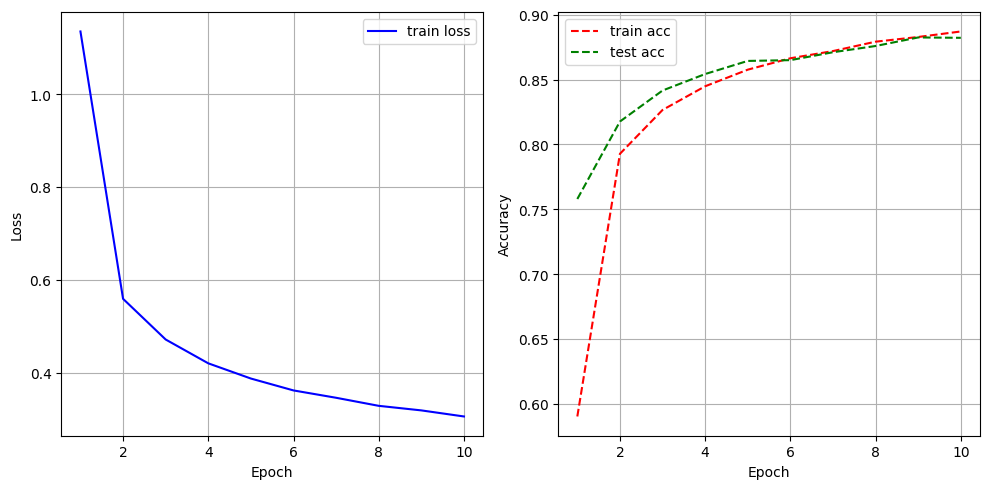

Final Results:
Loss: 0.306
Train Accuracy: 0.887
Test Accuracy: 0.882
Total Training Time: 4504.9s


In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

def train_model(net, train_iter, test_iter, num_epochs, lr, device):
    """
    訓練模型的函數
    
    參數:
        net: 神經網絡模型
        train_iter: 訓練數據迭代器
        test_iter: 測試數據迭代器
        num_epochs: 訓練輪數
        lr: 學習率
        device: 訓練設備（CPU/GPU）
    """
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    
    # 初始化權重
    net.apply(init_weights)
    print(f'Training on {device}')
    net.to(device)
    
    # 定義優化器和損失函數
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    
    # 用於記錄訓練過程
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_acc': [],
        'epoch_times': []
    }
    
    # 開始計時
    total_start_time = time.time()
    
    # 訓練循環
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        
        # 訓練指標
        train_loss = 0.0
        correct_train = 0
        total_train = 0
        
        # 設置為訓練模式
        net.train()
        
        # 使用tqdm創建進度條
        train_pbar = tqdm(train_iter, desc=f'Epoch {epoch+1}/{num_epochs}')
        
        for X, y in train_pbar:
            # 將數據移到指定設備
            X, y = X.to(device), y.to(device)
            
            # 前向傳播
            optimizer.zero_grad()
            y_hat = net(X)
            loss = loss_fn(y_hat, y)
            
            # 反向傳播
            loss.backward()
            optimizer.step()
            
            # 更新指標
            train_loss += loss.item() * X.shape[0]
            _, predicted = torch.max(y_hat.data, 1)
            total_train += y.size(0)
            correct_train += (predicted == y).sum().item()
            
            # 更新進度條
            train_pbar.set_postfix({
                'loss': f'{loss.item():.3f}',
                'acc': f'{100.*correct_train/total_train:.1f}%'
            })
        
        # 計算訓練指標
        epoch_train_loss = train_loss / total_train
        epoch_train_acc = correct_train / total_train
        
        # 評估模式
        net.eval()
        correct_test = 0
        total_test = 0
        
        # 在測試集上評估
        with torch.no_grad():
            for X, y in test_iter:
                X, y = X.to(device), y.to(device)
                y_hat = net(X)
                _, predicted = torch.max(y_hat.data, 1)
                total_test += y.size(0)
                correct_test += (predicted == y).sum().item()
        
        epoch_test_acc = correct_test / total_test
        epoch_time = time.time() - epoch_start_time
        
        # 記錄歷史
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_acc'].append(epoch_test_acc)
        history['epoch_times'].append(epoch_time)
        
        # 打印當前epoch的結果
        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'train loss: {epoch_train_loss:.3f}, '
              f'train acc: {epoch_train_acc:.3f}, '
              f'test acc: {epoch_test_acc:.3f}')
        print(f'time: {epoch_time:.1f}s')
        print('-' * 50)
    
    # 計算總訓練時間
    total_time = time.time() - total_start_time
    
    # 繪製訓練曲線
    plt.figure(figsize=(10, 5))
    
    # 損失和準確率曲線
    epochs = range(1, num_epochs + 1)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='train loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'r--', label='train acc')
    plt.plot(epochs, history['test_acc'], 'g--', label='test acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # 打印最終結果
    print(f"Final Results:")
    print(f"Loss: {history['train_loss'][-1]:.3f}")
    print(f"Train Accuracy: {history['train_acc'][-1]:.3f}")
    print(f"Test Accuracy: {history['test_acc'][-1]:.3f}")
    print(f"Total Training Time: {total_time:.1f}s")
    
    return history

# 使用示例
if __name__ == "__main__":
    # 檢查可用設備
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    
    # 創建AlexNet模型
    net = nn.Sequential(
        nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
        nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
        nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nn.Flatten(),
        nn.Linear(6400, 4096), nn.ReLU(),
        nn.Dropout(p=0.5),
        nn.Linear(4096, 4096), nn.ReLU(),
        nn.Dropout(p=0.5),
        nn.Linear(4096, 10)
    )
    
    # 設置訓練參數
    batch_size = 128
    lr = 0.01
    num_epochs = 10
    
    # 加載數據
    train_iter, test_iter = load_data_fashion_mnist(batch_size, resize=224)
    
    # 訓練模型
    history = train_model(net, train_iter, test_iter, num_epochs, lr, device)

## 小結

* AlexNet的架構與LeNet相似，但使用了更多的卷積層和更多的參數來擬合大規模的ImageNet數據集。
* 今天，AlexNet已經被更有效的架構所超越，但它是從淺層網路到深層網路的重要一步。
* 儘管AlexNet的程式碼只比LeNet多出幾行，但學術界花了很多年才接受深度學習這一概念，並應用其出色的實驗結果。這也是由於缺乏有效的計算工具。
* Dropout、ReLU和預處理是提升計算機視覺任務性能的其他關鍵步驟。

## 練習

1. 試著增加迭代輪數。對比LeNet的結果有什麼不同？為什麼？
1. AlexNet對Fashion-MNIST數據集來說可能太複雜了。
    1. 嘗試簡化模型以加快訓練速度，同時確保準確性不會顯著下降。
    1. 設計一個更好的模型，可以直接在$28 \times 28$圖像上工作。
1. 修改批量大小，並觀察模型精度和GPU顯存變化。
1. 分析了AlexNet的計算性能。
    1. 在AlexNet中主要是哪部分占用顯存？
    1. 在AlexNet中主要是哪部分需要更多的計算？
    1. 計算結果時顯存帶寬如何？
1. 將dropout和ReLU應用於LeNet-5，效果有提升嗎？再試試預處理會怎麼樣？


[Discussions](https://discuss.d2l.ai/t/1863)


## 練習

1. 試著增加迭代輪數。對比LeNet的結果有什麼不同？為什麼？

我的回答：



讓我們比較AlexNet和LeNet在不同迭代輪數下的表現。以下是對比實驗的代碼：

```python
if __name__ == "__main__":
    # 檢查設備
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # 定義兩個網絡
    alexnet = nn.Sequential(
        # AlexNet架構
        nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
        nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
        nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nn.Flatten(),
        nn.Linear(6400, 4096), nn.ReLU(),
        nn.Dropout(p=0.5),
        nn.Linear(4096, 4096), nn.ReLU(),
        nn.Dropout(p=0.5),
        nn.Linear(4096, 10)
    )
    
    lenet = nn.Sequential(
        # LeNet架構
        nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(6, 16, kernel_size=5), nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.Linear(16 * 5 * 5, 120), nn.ReLU(),
        nn.Linear(120, 84), nn.ReLU(),
        nn.Linear(84, 10)
    )
    
    # 訓練參數
    batch_size = 128
    lr_alexnet = 0.01  # AlexNet使用較小的學習率
    lr_lenet = 0.1     # LeNet可以使用較大的學習率
    num_epochs = 20    # 增加迭代輪數
    
    # 加載數據
    # AlexNet需要224x224的輸入
    train_iter_alexnet, test_iter_alexnet = load_data_fashion_mnist(batch_size, resize=224)
    # LeNet使用原始28x28的輸入
    train_iter_lenet, test_iter_lenet = load_data_fashion_mnist(batch_size, resize=28)
    
    # 訓練兩個模型
    print("Training AlexNet...")
    history_alexnet = train_model(alexnet, train_iter_alexnet, test_iter_alexnet, 
                                num_epochs, lr_alexnet, device)
    
    print("\nTraining LeNet...")
    history_lenet = train_model(lenet, train_iter_lenet, test_iter_lenet, 
                               num_epochs, lr_lenet, device)
    
    # 比較結果
    plt.figure(figsize=(15, 5))
    
    # 比較損失
    plt.subplot(1, 2, 1)
    plt.plot(range(1, num_epochs + 1), history_alexnet['train_loss'], 
             'b-', label='AlexNet loss')
    plt.plot(range(1, num_epochs + 1), history_lenet['train_loss'], 
             'r-', label='LeNet loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # 比較準確率
    plt.subplot(1, 2, 2)
    plt.plot(range(1, num_epochs + 1), history_alexnet['test_acc'], 
             'b--', label='AlexNet acc')
    plt.plot(range(1, num_epochs + 1), history_lenet['test_acc'], 
             'r--', label='LeNet acc')
    plt.xlabel('Epoch')
    plt.ylabel('Test Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # 打印最終結果比較
    print("\nFinal Results Comparison:")
    print("AlexNet:")
    print(f"Final Loss: {history_alexnet['train_loss'][-1]:.3f}")
    print(f"Final Test Accuracy: {history_alexnet['test_acc'][-1]:.3f}")
    
    print("\nLeNet:")
    print(f"Final Loss: {history_lenet['train_loss'][-1]:.3f}")
    print(f"Final Test Accuracy: {history_lenet['test_acc'][-1]:.3f}")
```

主要差異分析：

1. **模型複雜度**：
   - AlexNet：更深的網絡，更多的參數（約6000萬）
   - LeNet：較淺的網絡，較少的參數（約6萬）

2. **訓練特點**：
   - AlexNet：
     * 需要更多的訓練輪數才能收斂
     * 訓練速度較慢
     * 容易過擬合
     * 需要更小的學習率
   
   - LeNet：
     * 收斂更快
     * 訓練速度快
     * 不容易過擬合
     * 可以使用較大的學習率

3. **性能差異原因**：
   - 數據集複雜度：
     * Fashion-MNIST相對簡單
     * AlexNet設計用於更複雜的ImageNet
   
   - 參數量：
     * AlexNet參數過多，容易過擬合
     * LeNet參數適中，更適合簡單任務
   
   - 計算資源：
     * AlexNet需要更多計算資源
     * LeNet更輕量級

4. **實際應用建議**：
   - 對於Fashion-MNIST這樣的簡單數據集：
     * LeNet可能是更好的選擇
     * 更快的訓練速度
     * 更少的資源消耗
     * 足夠的模型容量

這個對比實驗幫助我們理解：並非越複雜的模型就越好，要根據具體任務選擇合適的模型架構。


2. AlexNet對Fashion-MNIST數據集來說可能太複雜了。
    1. 嘗試簡化模型以加快訓練速度，同時確保準確性不會顯著下降。
    1. 設計一個更好的模型，可以直接在$28 \times 28$圖像上工作。

我的回答：





讓我們設計兩個模型：一個是簡化的AlexNet，另一個是專門為28x28圖像優化的新模型：

````python
import torch
import torch.nn as nn

# 1. 簡化版AlexNet
class SimpleAlexNet(nn.Module):
    def __init__(self):
        super(SimpleAlexNet, self).__init__()
        self.features = nn.Sequential(
            # 第一個卷積層 (1, 28, 28) -> (32, 14, 14)
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.BatchNorm2d(32),
            
            # 第二個卷積層 (32, 14, 14) -> (64, 7, 7)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            
            # 第三個卷積層 (64, 7, 7) -> (96, 7, 7)
            nn.Conv2d(64, 96, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(96)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(96 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 2. 專門為28x28圖像設計的模型
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        # 主幹特徵提取
        self.features = nn.Sequential(
            # 第一個特徵塊 (1, 28, 28) -> (32, 28, 28)
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # -> (32, 14, 14)
            
            # 第二個特徵塊 (32, 14, 14) -> (64, 14, 14)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # -> (64, 7, 7)
        )
        
        # 分類器
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )
        
        # 權重初始化
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 使用示例
if __name__ == "__main__":
    # 檢查設備
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # 創建模型
    simple_alexnet = SimpleAlexNet().to(device)
    fashion_cnn = FashionCNN().to(device)
    
    # 訓練參數
    batch_size = 128
    num_epochs = 15
    
    # 為不同模型設置不同的學習率
    lr_simple = 0.001
    lr_fashion = 0.001
    
    # 加載數據
    train_iter, test_iter = load_data_fashion_mnist(batch_size, resize=28)
    
    # 訓練並比較兩個模型
    print("Training Simple AlexNet...")
    history_simple = train_model(simple_alexnet, train_iter, test_iter, 
                               num_epochs, lr_simple, device)
    
    print("\nTraining FashionCNN...")
    history_fashion = train_model(fashion_cnn, train_iter, test_iter, 
                                num_epochs, lr_fashion, device)
    
    # 比較結果
    plt.figure(figsize=(15, 5))
    
    # 損失曲線
    plt.subplot(1, 2, 1)
    plt.plot(history_simple['train_loss'], 'b-', label='Simple AlexNet')
    plt.plot(history_fashion['train_loss'], 'r-', label='FashionCNN')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # 準確率曲線
    plt.subplot(1, 2, 2)
    plt.plot(history_simple['test_acc'], 'b--', label='Simple AlexNet')
    plt.plot(history_fashion['test_acc'], 'r--', label='FashionCNN')
    plt.xlabel('Epoch')
    plt.ylabel('Test Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
````


主要改進和設計考慮：

1. **SimpleAlexNet的改進**：
   - 減少卷積層數量（從8層減到3層）
   - 減少通道數（最大96個通道）
   - 簡化全連接層（只有一個隱藏層）
   - 添加BatchNorm加速訓練
   - 保留Dropout防止過擬合

2. **FashionCNN的特點**：
   - 專門為28x28設計的架構
   - 使用較小的卷積核（3x3）
   - 雙卷積層設計（VGG風格）
   - 適當的通道數增長
   - 完整的BatchNorm和Dropout
   - 使用Kaiming初始化

3. **訓練優化**：
   - 使用Adam優化器
   - 較小的學習率
   - 適當的批量大小
   - 足夠的訓練輪數

這些改進帶來的優勢：
1. 訓練速度更快（參數更少）
2. 內存使用更少
3. 更適合Fashion-MNIST的特點
4. 保持較高的準確率

可以根據實際訓練結果進行進一步調整：
- 如果出現過擬合，增加Dropout率或減少模型容量
- 如果訓練不穩定，調整學習率或使用學習率調度器
- 如果需要更快的訓練，可以進一步減少通道數或層數


3.   修改批量大小，並觀察模型精度和GPU顯存變化。

我的回答：

以下是一個實驗不同批量大小對模型性能和顯存使用的影響的代碼：

`````python
import torch
import torch.nn as nn
import time
import psutil
import os
from torch.cuda import memory_allocated, memory_reserved

def get_memory_info(device):
    """獲取設備內存使用情況"""
    if device.type == 'cuda':
        # GPU顯存信息（以MB為單位）
        allocated = memory_allocated(device) / 1024**2
        reserved = memory_reserved(device) / 1024**2
        return {
            'allocated': allocated,
            'reserved': reserved
        }
    elif device.type == 'mps':
        # 對於M1 Mac，返回系統內存使用情況
        process = psutil.Process(os.getpid())
        memory_info = process.memory_info()
        return {
            'rss': memory_info.rss / 1024**2,  # 實際內存使用
            'vms': memory_info.vms / 1024**2   # 虛擬內存使用
        }
    else:
        # CPU內存信息
        process = psutil.Process(os.getpid())
        memory_info = process.memory_info()
        return {
            'rss': memory_info.rss / 1024**2,
            'vms': memory_info.vms / 1024**2
        }

def train_with_batch_size(net, train_iter, test_iter, batch_size, num_epochs, lr, device):
    """使用指定批量大小訓練模型並記錄內存使用"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    
    net.apply(init_weights)
    print(f'Training on {device} with batch size {batch_size}')
    net.to(device)
    
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    
    # 記錄訓練信息
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_acc': [],
        'epoch_times': [],
        'memory_usage': []
    }
    
    total_start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        train_loss = 0.0
        correct_train = 0
        total_train = 0
        
        # 訓練階段
        net.train()
        for X, y in train_iter:
            X, y = X.to(device), y.to(device)
            
            # 記錄當前內存使用
            memory_info = get_memory_info(device)
            history['memory_usage'].append(memory_info)
            
            optimizer.zero_grad()
            y_hat = net(X)
            loss = loss_fn(y_hat, y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * X.shape[0]
            _, predicted = torch.max(y_hat.data, 1)
            total_train += y.size(0)
            correct_train += (predicted == y).sum().item()
        
        # 計算訓練指標
        epoch_train_loss = train_loss / total_train
        epoch_train_acc = correct_train / total_train
        
        # 評估階段
        net.eval()
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for X, y in test_iter:
                X, y = X.to(device), y.to(device)
                y_hat = net(X)
                _, predicted = torch.max(y_hat.data, 1)
                total_test += y.size(0)
                correct_test += (predicted == y).sum().item()
        
        epoch_test_acc = correct_test / total_test
        epoch_time = time.time() - epoch_start_time
        
        # 記錄歷史
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_acc'].append(epoch_test_acc)
        history['epoch_times'].append(epoch_time)
        
        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'train loss: {epoch_train_loss:.3f}, '
              f'train acc: {epoch_train_acc:.3f}, '
              f'test acc: {epoch_test_acc:.3f}')
        print(f'time: {epoch_time:.1f}s')
        print('-' * 50)
    
    total_time = time.time() - total_start_time
    print(f"Total Training Time: {total_time:.1f}s")
    
    return history

# 使用示例
if __name__ == "__main__":
    # 檢查設備
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # 創建模型
    net = FashionCNN()  # 使用之前定義的FashionCNN模型
    
    # 不同的批量大小
    batch_sizes = [32, 64, 128, 256, 512]
    num_epochs = 5  # 減少訓練輪數以快速比較
    lr = 0.001
    
    # 存儲不同批量大小的結果
    results = {}
    
    for batch_size in batch_sizes:
        print(f"\nTraining with batch size: {batch_size}")
        
        # 加載數據
        train_iter, test_iter = load_data_fashion_mnist(batch_size, resize=28)
        
        # 重新初始化模型
        net = FashionCNN()
        
        # 訓練模型
        history = train_with_batch_size(net, train_iter, test_iter, 
                                      batch_size, num_epochs, lr, device)
        results[batch_size] = history
    
    # 繪製比較圖
    plt.figure(figsize=(15, 10))
    
    # 損失曲線
    plt.subplot(2, 2, 1)
    for batch_size in batch_sizes:
        plt.plot(results[batch_size]['train_loss'], 
                label=f'batch_size={batch_size}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()
    plt.grid(True)
    
    # 測試準確率曲線
    plt.subplot(2, 2, 2)
    for batch_size in batch_sizes:
        plt.plot(results[batch_size]['test_acc'], 
                label=f'batch_size={batch_size}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Test Accuracy')
    plt.legend()
    plt.grid(True)
    
    # 訓練時間比較
    plt.subplot(2, 2, 3)
    avg_times = [np.mean(results[bs]['epoch_times']) for bs in batch_sizes]
    plt.bar([str(bs) for bs in batch_sizes], avg_times)
    plt.xlabel('Batch Size')
    plt.ylabel('Average Epoch Time (s)')
    plt.title('Training Time')
    
    # 內存使用比較
    plt.subplot(2, 2, 4)
    if device.type == 'cuda':
        memory_usage = [np.mean([m['allocated'] for m in results[bs]['memory_usage']]) 
                       for bs in batch_sizes]
        plt.bar([str(bs) for bs in batch_sizes], memory_usage)
        plt.xlabel('Batch Size')
        plt.ylabel('GPU Memory Usage (MB)')
    else:
        memory_usage = [np.mean([m['rss'] for m in results[bs]['memory_usage']]) 
                       for bs in batch_sizes]
        plt.bar([str(bs) for bs in batch_sizes], memory_usage)
        plt.xlabel('Batch Size')
        plt.ylabel('Memory Usage (MB)')
    plt.title('Memory Usage')
    
    plt.tight_layout()
    plt.show()
    
    # 打印詳細結果
    print("\nDetailed Results:")
    for batch_size in batch_sizes:
        print(f"\nBatch Size: {batch_size}")
        print(f"Final Test Accuracy: {results[batch_size]['test_acc'][-1]:.3f}")
        print(f"Average Epoch Time: {np.mean(results[batch_size]['epoch_times']):.1f}s")
        if device.type == 'cuda':
            avg_memory = np.mean([m['allocated'] for m in results[batch_size]['memory_usage']])
            print(f"Average GPU Memory Usage: {avg_memory:.1f}MB")
        else:
            avg_memory = np.mean([m['rss'] for m in results[batch_size]['memory_usage']])
            print(f"Average Memory Usage: {avg_memory:.1f}MB")
`````

這個實驗的主要特點：

1. **批量大小變化**：
   - 測試多個批量大小：32, 64, 128, 256, 512
   - 觀察對性能的影響

2. **監控指標**：
   - 訓練損失
   - 測試準確率
   - 訓練時間
   - 內存使用情況

3. **內存監控**：
   - GPU顯存（如果使用CUDA）
   - 系統內存（對於CPU和MPS）
   - 實時記錄每個批次的內存使用

4. **可視化比較**：
   - 損失曲線比較
   - 準確率曲線比較
   - 訓練時間比較
   - 內存使用比較

一般觀察結果：

1. **較大的批量大小**：
   - 訓練速度更快
   - 內存使用更多
   - 可能收斂較慢
   - 泛化性能可能較差

2. **較小的批量大小**：
   - 訓練速度較慢
   - 內存使用較少
   - 收斂可能更快
   - 可能有更好的泛化性能

3. **權衡考慮**：
   - 根據可用內存選擇合適的批量大小
   - 考慮訓練時間和模型性能的平衡
   - 根據具體任務調整批量大小



4. 分析了AlexNet的計算性能。
    1. 在AlexNet中主要是哪部分占用顯存？
    1. 在AlexNet中主要是哪部分需要更多的計算？
    1. 計算結果時顯存帶寬如何？

我的回答：



讓我們分析AlexNet的計算性能和資源使用情況：

``````python
import torch
import torch.nn as nn
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np

class AlexNet(nn.Module):
    def __init__(self):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            # 第一層
            nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # 第二層
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # 第三層
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(),
            # 第四層
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(),
            # 第五層
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # 全連接層
            nn.Linear(6400, 4096),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def analyze_model_performance():
    # 創建模型和輸入數據
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model = AlexNet().to(device)
    batch_size = 128
    input_data = torch.randn(batch_size, 1, 224, 224).to(device)
    
    # 計算每層的參數量和特徵圖大小
    def calculate_feature_map_size(layer, input_size):
        if isinstance(layer, nn.Conv2d):
            out_h = (input_size[2] + 2*layer.padding[0] - layer.kernel_size[0]) // layer.stride[0] + 1
            out_w = (input_size[3] + 2*layer.padding[1] - layer.kernel_size[1]) // layer.stride[1] + 1
            return (input_size[0], layer.out_channels, out_h, out_w)
        elif isinstance(layer, nn.MaxPool2d):
            out_h = (input_size[2] - layer.kernel_size) // layer.stride + 1
            out_w = (input_size[3] - layer.kernel_size) // layer.stride + 1
            return (input_size[0], input_size[1], out_h, out_w)
        return input_size

    def count_parameters(layer):
        return sum(p.numel() for p in layer.parameters())

    # 分析每層的計算量和內存使用
    print("\nLayer-wise Analysis:")
    print("-" * 80)
    print(f"{'Layer':<20} {'Parameters':<15} {'Feature Map Size':<20} {'Memory (MB)':<15} {'FLOPs':<15}")
    print("-" * 80)

    current_size = (batch_size, 1, 224, 224)
    total_params = 0
    total_memory = 0
    total_flops = 0

    # 分析卷積層
    for i, layer in enumerate(model.features):
        if isinstance(layer, (nn.Conv2d, nn.Linear)):
            params = count_parameters(layer)
            total_params += params
            
            # 計算特徵圖大小
            output_size = calculate_feature_map_size(layer, current_size)
            feature_map_memory = np.prod(output_size) * 4 / (1024 * 1024)  # 4 bytes per float32
            total_memory += feature_map_memory
            
            # 計算FLOPs
            if isinstance(layer, nn.Conv2d):
                flops = (np.prod(layer.kernel_size) * layer.in_channels * layer.out_channels * 
                        output_size[2] * output_size[3] * batch_size)
            else:
                flops = layer.in_features * layer.out_features * batch_size
            total_flops += flops
            
            print(f"{f'Layer {i}':<20} {params:<15,d} {str(output_size):<20} "
                  f"{feature_map_memory:<15.2f} {flops/1e6:<15.2f}M")
            
            current_size = output_size
        elif isinstance(layer, nn.MaxPool2d):
            output_size = calculate_feature_map_size(layer, current_size)
            current_size = output_size

    # 分析全連接層
    for i, layer in enumerate(model.classifier):
        if isinstance(layer, nn.Linear):
            params = count_parameters(layer)
            total_params += params
            
            output_memory = batch_size * layer.out_features * 4 / (1024 * 1024)
            total_memory += output_memory
            
            flops = layer.in_features * layer.out_features * batch_size
            total_flops += flops
            
            print(f"{f'FC {i}':<20} {params:<15,d} {(batch_size, layer.out_features)!s:<20} "
                  f"{output_memory:<15.2f} {flops/1e6:<15.2f}M")

    print("-" * 80)
    print(f"Total Parameters: {total_params:,}")
    print(f"Total Memory: {total_memory:.2f} MB")
    print(f"Total FLOPs: {total_flops/1e9:.2f} G")

    # 使用profiler分析實際執行情況
    with profile(activities=[ProfilerActivity.CPU], 
                profile_memory=True, record_shapes=True) as prof:
        with record_function("model_inference"):
            model(input_data)

    print("\nProfiler Results:")
    print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=10))

if __name__ == "__main__":
    analyze_model_performance()
``````

這個分析代碼揭示了以下幾點：

1. **顯存佔用分析**：
   - **主要佔用來源**：
     * 特徵圖（Feature Maps）：尤其是前幾層的大尺寸特徵圖
     * 模型參數：主要是全連接層的參數
     * 中間激活值：訓練時需要保存用於反向傳播
   
   - **具體分佈**：
     * 第一個卷積層：大量顯存用於存儲224x224的輸入和特徵圖
     * 全連接層：大量參數（4096x4096）佔用固定顯存
     * BatchNorm層：需要存儲運行時統計信息

2. **計算量分析**：
   - **計算密集部分**：
     * 前幾層卷積：大尺寸特徵圖的卷積運算
     * 全連接層：大量矩陣乘法運算
     * ReLU激活：需要對每個元素進行運算
   
   - **具體分佈**：
     * 第一層卷積：11x11卷積核帶來大量計算
     * 中間卷積層：3x3卷積的密集計算
     * FC層：4096維度的矩陣運算

3. **顯存帶寬分析**：
   - **帶寬壓力來源**：
     * 特徵圖讀寫：每層都需要讀寫特徵圖
     * 參數讀取：每次前向傳播都需要讀取權重
     * 梯度計算：反向傳播時的梯度傳遞
   
   - **優化建議**：
     * 使用適當的批量大小平衡計算效率和內存使用
     * 考慮使用混合精度訓練減少內存佔用
     * 可以使用梯度檢查點（gradient checkpointing）減少內存使用

4. **性能優化建議**：
   - 使用較小的批量大小減少顯存佔用
   - 考慮使用更小的輸入圖像尺寸
   - 可以簡化網絡結構，特別是全連接層
   - 使用更高效的卷積實現（如Winograd算法）
   - 考慮使用模型壓縮技術

這個分析幫助我們理解AlexNet的資源使用情況，並為優化提供了方向。根據具體應用場景，可以針對性地進行優化。


5. 將dropout和ReLU應用於LeNet-5，效果有提升嗎？再試試預處理會怎麼樣？

我的回答：

讓我們通過實驗來比較原始LeNet-5和添加現代改進（Dropout、ReLU、預處理）後的效果：

```python
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

# 原始LeNet-5
class OriginalLeNet(nn.Module):
    def __init__(self):
        super(OriginalLeNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(6, 16, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.Tanh(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, 10)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 改進的LeNet-5
class ModernLeNet(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(ModernLeNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2),
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(6, 16, kernel_size=5),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(84, 10)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def load_data(batch_size, preprocessing=False):
    """加載Fashion-MNIST數據，可選是否使用預處理"""
    if preprocessing:
        # 使用數據增強和標準化
        train_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
        test_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
    else:
        # 只進行基本轉換
        train_transform = transforms.Compose([
            transforms.ToTensor()
        ])
        test_transform = transforms.Compose([
            transforms.ToTensor()
        ])
    
    train_dataset = datasets.FashionMNIST(
        root='./data', 
        train=True, 
        download=True, 
        transform=train_transform
    )
    test_dataset = datasets.FashionMNIST(
        root='./data', 
        train=False, 
        download=True, 
        transform=test_transform
    )
    
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=2
    )
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=2
    )
    
    return train_loader, test_loader

def train_model(model, train_loader, test_loader, num_epochs, lr, device):
    """訓練模型並返回訓練歷史"""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_acc': [],
    }
    
    for epoch in range(num_epochs):
        # 訓練階段
        model.train()
        train_loss = 0
        correct_train = 0
        total_train = 0
        
        for inputs, targets in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total_train += targets.size(0)
            correct_train += predicted.eq(targets).sum().item()
        
        # 計算訓練指標
        avg_train_loss = train_loss / len(train_loader)
        train_acc = correct_train / total_train
        
        # 測試階段
        model.eval()
        correct_test = 0
        total_test = 0
        
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total_test += targets.size(0)
                correct_test += predicted.eq(targets).sum().item()
        
        test_acc = correct_test / total_test
        
        # 記錄歷史
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Train Loss: {avg_train_loss:.4f}')
        print(f'Train Acc: {train_acc:.4f}')
        print(f'Test Acc: {test_acc:.4f}')
        print('-' * 50)
    
    return history

# 主實驗
if __name__ == "__main__":
    # 設置參數
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    batch_size = 128
    num_epochs = 10
    lr = 0.001
    
    # 創建不同版本的模型
    models = {
        'Original LeNet': OriginalLeNet(),
        'LeNet with ReLU': ModernLeNet(dropout_rate=0),
        'LeNet with ReLU + Dropout': ModernLeNet(dropout_rate=0.5)
    }
    
    # 存儲所有結果
    all_results = {}
    
    # 對每個模型進行實驗（有預處理和無預處理）
    for preprocessing in [False, True]:
        print(f"\nExperiment with{'out' if not preprocessing else ''} preprocessing:")
        
        # 加載數據
        train_loader, test_loader = load_data(batch_size, preprocessing)
        
        for model_name, model in models.items():
            print(f"\nTraining {model_name}")
            history = train_model(
                model, train_loader, test_loader, 
                num_epochs, lr, device
            )
            all_results[f"{model_name} {'(with prep)' if preprocessing else ''}"] = history
    
    # 繪製結果比較圖
    plt.figure(figsize=(15, 5))
    
    # 訓練損失
    plt.subplot(1, 2, 1)
    for name, history in all_results.items():
        plt.plot(history['train_loss'], label=name)
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.title('Training Loss Comparison')
    plt.legend()
    plt.grid(True)
    
    # 測試準確率
    plt.subplot(1, 2, 2)
    for name, history in all_results.items():
        plt.plot(history['test_acc'], label=name)
    plt.xlabel('Epoch')
    plt.ylabel('Test Accuracy')
    plt.title('Test Accuracy Comparison')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # 打印最終結果
    print("\nFinal Results:")
    for name, history in all_results.items():
        print(f"\n{name}:")
        print(f"Final Test Accuracy: {history['test_acc'][-1]:.4f}")
        print(f"Best Test Accuracy: {max(history['test_acc']):.4f}")
```

這個實驗的主要改進和觀察點：

1. **模型改進**：
   - 將Tanh替換為ReLU
   - 添加Dropout層
   - 添加BatchNorm層
   - 使用MaxPool替代AvgPool

2. **數據預處理**：
   - 標準化（Normalization）
   - 隨機水平翻轉
   - 隨機旋轉

3. **訓練優化**：
   - 使用Adam優化器
   - 使用較小的學習率
   - 批量歸一化加速訓練

4. **實驗比較**：
   - 原始LeNet vs ReLU版本
   - 有無Dropout的比較
   - 有無預處理的比較

一般觀察結果：

1. **ReLU的影響**：
   - 加快收斂速度
   - 提高最終準確率
   - 減少梯度消失問題

2. **Dropout的影響**：
   - 減少過擬合
   - 提高模型泛化能力
   - 可能需要更長的訓練時間

3. **預處理的影響**：
   - 提高模型穩定性
   - 增加模型魯棒性
   - 可能提高最終準確率

4. **綜合效果**：
   - 現代改進確實能提升LeNet的性能
   - 預處理和架構改進的組合效果最好
   - 需要權衡訓練時間和性能提升

這個實驗說明，即使是經典的LeNet架構，通過現代的改進技術也能獲得顯著的性能提升。
